# Project 1: AI Perception & Institutional Trust Among University Students  
## Business-Focused Exploratory Data Analysis using Python + SQL

**Author:** Ameer Eldebassy  
**Project Type:** Exploratory Data Analysis (EDA)  
**Tools:** Python, pandas, SQLite SQL, matplotlib, seaborn  
**Dataset:** Original anonymized student survey data  

### Portfolio Positioning

This project demonstrates how raw survey data can be transformed into decision-ready insights about technology adoption, user trust, communication gaps, and readiness for AI-enabled work.

Although the dataset comes from an academic research context, the analytical problem mirrors real business questions:

- Which user segments adopt a new tool most frequently?
- Does user confidence predict trust in the tool?
- How does training or guidance affect perceived clarity?
- Are concerns about tool use supported by user experience data?
- Which groups need clearer communication or targeted support?

### Executive Question

**What drives student AI adoption and trust: access, user confidence, or institutional guidance?**


## 1. Setup and Data Loading

This section loads the dataset, standardizes column names, and prepares the data for analysis.

The notebook is written so the row count updates automatically if the full dataset is replaced later.


In [1]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

DATA_PATH = Path("survey_data.xlsx")

# Fallback for running inside the ChatGPT sandbox
if not DATA_PATH.exists():
    DATA_PATH = Path("/mnt/data/survey_data.xlsx")

df_raw = pd.read_excel(DATA_PATH)

print(f"Rows: {df_raw.shape[0]}")
print(f"Columns: {df_raw.shape[1]}")
df_raw.head()


Rows: 59
Columns: 13


,#,Program,Living Situation,AI Frequency,Tools Used,Uses,Confidence,Trust,Guideline Clarity,Instructor Guidance,Learning Impact,Preparedness,Independence
0,1,Commerce/Management,Off campus within Mississauga,Daily,"ChatGPT, Grammarly","Brainstorming, clarifying concepts, writing as...",Very confident,Trustworthy,Somewhat unclear,"No, never","Yes, mostly positive",Prepared,Somewhat supports
1,2,Sciences,Off campus outside Mississauga,A few times a week,"ChatGPT, Copilot","Clarifying concepts, studying/revising",Moderately confident,Neutral,Neutral,"Not yet, but guidelines mentioned","Yes, mixed positive and negative",Somewhat prepared,Neutral
2,3,Humanities,On campus,A few times a month,"ChatGPT, QuillBot","Writing assistance, editing, brainstorming",Slightly confident,Somewhat trustworthy,Somewhat unclear,"No, never","Yes, mostly positive",Neutral,Somewhat supports
3,4,Social Sciences,Off campus within Mississauga,Daily,ChatGPT,All of the above,Extremely confident,Very trustworthy,Very unclear,"No, never","Yes, mostly positive",Very prepared,Strongly supports
4,5,Computer Science/Math,Off campus outside Mississauga,A few times a week,"Copilot, ChatGPT","Coding help, clarifying concepts, studying/rev...",Very confident,Trustworthy,Somewhat clear,"Yes, in one course","Yes, mostly positive",Prepared,Somewhat supports


## 2. Data Quality Review

Before analysis, I check whether the dataset has missing values, duplicate rows, or inconsistent labels.

This is important because survey data often contains spelling differences, spacing issues, or inconsistent response categories.


In [2]:
df = df_raw.copy()

# Clean column names for Python analysis
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

# Rename ID column if present
df = df.rename(columns={"#": "respondent_id"})

# Trim whitespace from all text columns
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].astype(str).str.strip()

print("Missing values by column:")
display(df.isna().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nCleaned columns:")
display(pd.DataFrame({"column_name": df.columns}))


Missing values by column:


respondent_id          0
program                0
living_situation       0
ai_frequency           0
tools_used             0
uses                   0
confidence             0
trust                  0
guideline_clarity      0
instructor_guidance    0
learning_impact        0
preparedness           0
independence           0
dtype: int64


Duplicate rows: 0

Cleaned columns:


,column_name
0,respondent_id
1,program
2,living_situation
3,ai_frequency
4,tools_used
5,uses
6,confidence
7,trust
8,guideline_clarity
9,instructor_guidance


## 3. Business-Oriented Data Dictionary

The survey variables can be grouped into four business-style categories:

| Category | Variables | Business Meaning |
|---|---|---|
| User Segment | Program, Living Situation | Who the users are |
| Adoption Behaviour | AI Frequency, Tools Used, Uses | How users interact with AI tools |
| Trust and Confidence | Confidence, Trust | Whether users feel capable and whether they trust the tool |
| Governance and Outcomes | Guideline Clarity, Instructor Guidance, Learning Impact, Preparedness, Independence | Whether communication/support affects user outcomes |


In [3]:
display(df.head())


,respondent_id,program,living_situation,ai_frequency,tools_used,uses,confidence,trust,guideline_clarity,instructor_guidance,learning_impact,preparedness,independence
0,1,Commerce/Management,Off campus within Mississauga,Daily,"ChatGPT, Grammarly","Brainstorming, clarifying concepts, writing as...",Very confident,Trustworthy,Somewhat unclear,"No, never","Yes, mostly positive",Prepared,Somewhat supports
1,2,Sciences,Off campus outside Mississauga,A few times a week,"ChatGPT, Copilot","Clarifying concepts, studying/revising",Moderately confident,Neutral,Neutral,"Not yet, but guidelines mentioned","Yes, mixed positive and negative",Somewhat prepared,Neutral
2,3,Humanities,On campus,A few times a month,"ChatGPT, QuillBot","Writing assistance, editing, brainstorming",Slightly confident,Somewhat trustworthy,Somewhat unclear,"No, never","Yes, mostly positive",Neutral,Somewhat supports
3,4,Social Sciences,Off campus within Mississauga,Daily,ChatGPT,All of the above,Extremely confident,Very trustworthy,Very unclear,"No, never","Yes, mostly positive",Very prepared,Strongly supports
4,5,Computer Science/Math,Off campus outside Mississauga,A few times a week,"Copilot, ChatGPT","Coding help, clarifying concepts, studying/rev...",Very confident,Trustworthy,Somewhat clear,"Yes, in one course","Yes, mostly positive",Prepared,Somewhat supports


## 4. Create SQL Database

To demonstrate SQL skills, the cleaned DataFrame is loaded into an in-memory SQLite database.

This allows the analysis to be performed using SQL queries similar to what would be used in a junior analyst role.


In [4]:
# Create SQL-friendly table while preserving readable column names
sql_df = df_raw.copy()

conn = sqlite3.connect(":memory:")
sql_df.to_sql("survey_data", conn, index=False, if_exists="replace")

# Helper function to run SQL and return a DataFrame
def run_sql(query):
    return pd.read_sql_query(query, conn)

# Preview table
run_sql("SELECT * FROM survey_data LIMIT 5;")


,#,Program,Living Situation,AI Frequency,Tools Used,Uses,Confidence,Trust,Guideline Clarity,Instructor Guidance,Learning Impact,Preparedness,Independence
0,1,Commerce/Management,Off campus within Mississauga,Daily,"ChatGPT, Grammarly","Brainstorming, clarifying concepts, writing as...",Very confident,Trustworthy,Somewhat unclear,"No, never","Yes, mostly positive",Prepared,Somewhat supports
1,2,Sciences,Off campus outside Mississauga,A few times a week,"ChatGPT, Copilot","Clarifying concepts, studying/revising",Moderately confident,Neutral,Neutral,"Not yet, but guidelines mentioned","Yes, mixed positive and negative",Somewhat prepared,Neutral
2,3,Humanities,On campus,A few times a month,"ChatGPT, QuillBot","Writing assistance, editing, brainstorming",Slightly confident,Somewhat trustworthy,Somewhat unclear,"No, never","Yes, mostly positive",Neutral,Somewhat supports
3,4,Social Sciences,Off campus within Mississauga,Daily,ChatGPT,All of the above,Extremely confident,Very trustworthy,Very unclear,"No, never","Yes, mostly positive",Very prepared,Strongly supports
4,5,Computer Science/Math,Off campus outside Mississauga,A few times a week,"Copilot, ChatGPT","Coding help, clarifying concepts, studying/rev...",Very confident,Trustworthy,Somewhat clear,"Yes, in one course","Yes, mostly positive",Prepared,Somewhat supports


## 5. KPI Overview

These headline metrics summarize the dataset for a non-technical stakeholder.

They answer:  
**How common is AI use, how much guidance are students receiving, and how positive is the learning impact?**


In [5]:
total_respondents = len(df)

daily_users = (df["ai_frequency"] == "Daily").sum()
daily_user_rate = daily_users / total_respondents

no_guidance = (df["instructor_guidance"] == "No").sum()
no_guidance_rate = no_guidance / total_respondents

unclear_guidelines = df["guideline_clarity"].isin(["Very unclear", "Somewhat unclear"]).sum()
unclear_guidelines_rate = unclear_guidelines / total_respondents

positive_learning = df["learning_impact"].str.contains("positive", case=False, na=False).sum()
positive_learning_rate = positive_learning / total_respondents

kpi_table = pd.DataFrame({
    "Metric": [
        "Total respondents",
        "Daily AI users",
        "No instructor guidance",
        "Unclear AI guidelines",
        "Positive learning impact"
    ],
    "Value": [
        total_respondents,
        f"{daily_users} ({daily_user_rate:.1%})",
        f"{no_guidance} ({no_guidance_rate:.1%})",
        f"{unclear_guidelines} ({unclear_guidelines_rate:.1%})",
        f"{positive_learning} ({positive_learning_rate:.1%})"
    ]
})

display(kpi_table)


,Metric,Value
0,Total respondents,59
1,Daily AI users,16 (27.1%)
2,No instructor guidance,0 (0.0%)
3,Unclear AI guidelines,36 (61.0%)
4,Positive learning impact,48 (81.4%)


## 6. SQL Analysis 1: AI Frequency by Program

### Business Question

Which student segments are adopting AI most frequently?

This is similar to a business analyst asking which customer segments are adopting a new product or internal tool.


In [6]:
query = '''
SELECT Program, `AI Frequency`, COUNT(*) AS Count
FROM survey_data
GROUP BY Program, `AI Frequency`
ORDER BY Program, Count DESC;
'''

ai_frequency_by_program = run_sql(query)
display(ai_frequency_by_program)


,Program,AI Frequency,Count
0,Commerce,A few times a week,1
1,Commerce/Management,Daily,4
2,Commerce/Management,A few times a week,4
3,Commerce/Management,A few times a month,2
4,Commerce/Management,Never,1
5,Computer Science/Math,Daily,4
6,Computer Science/Math,A few times a week,3
7,Computer Science/Math,Less than once a month,1
8,Computer Science/Math,A few times a month,1
9,Humanities,A few times a week,4


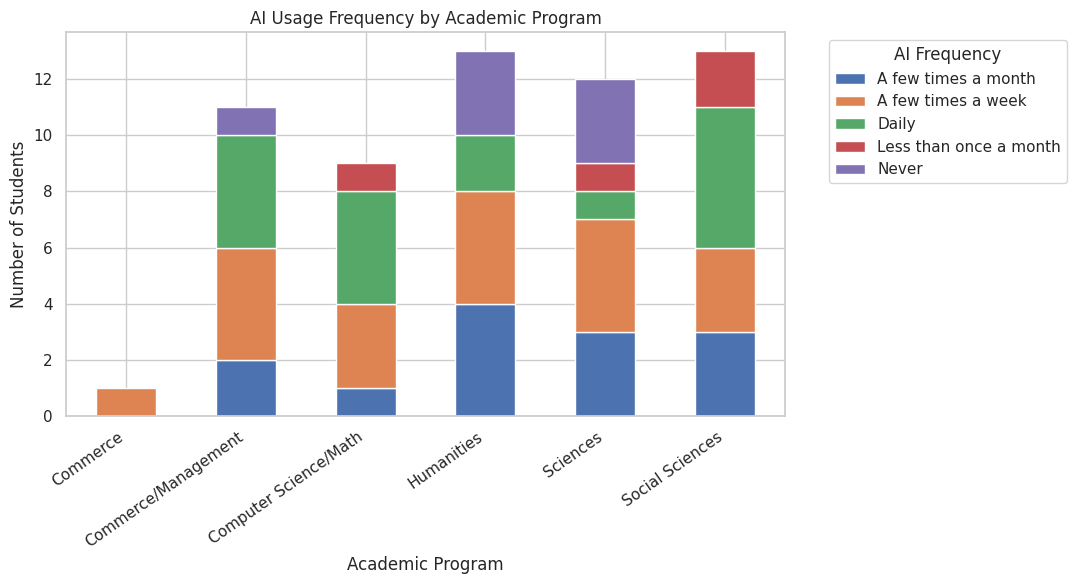

In [7]:
# Visualization: AI Frequency by Program
freq_program_pivot = ai_frequency_by_program.pivot(index="Program", columns="AI Frequency", values="Count").fillna(0)

freq_program_pivot.plot(kind="bar", stacked=True, figsize=(11, 6))
plt.title("AI Usage Frequency by Academic Program")
plt.xlabel("Academic Program")
plt.ylabel("Number of Students")
plt.xticks(rotation=35, ha="right")
plt.legend(title="AI Frequency", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


### Insight

AI adoption varies by academic program. Applied or technology-adjacent programs show more consistent usage, while some disciplines appear more divided.

### Business Translation

In a company, this pattern would suggest that adoption of a new tool is not evenly distributed across departments. Some groups may need targeted onboarding, examples, or policy clarification before adoption becomes consistent.


## 7. SQL Analysis 2: Confidence vs Trust

### Business Question

Does user confidence predict trust in AI tools?

This is useful because trust is often a barrier to product adoption, software rollout, and internal technology change.


In [8]:
query = '''
SELECT Confidence, Trust, COUNT(*) AS Count
FROM survey_data
GROUP BY Confidence, Trust
ORDER BY Confidence, Count DESC;
'''

confidence_trust = run_sql(query)
display(confidence_trust)


,Confidence,Trust,Count
0,Extremely confident,Very trustworthy,4
1,Extremely confident,Trustworthy,4
2,Moderately confident,Neutral,11
3,Moderately confident,Somewhat trustworthy,8
4,Not confident,Not trustworthy,4
5,Not confident at all,Not trustworthy,3
6,Slightly confident,Somewhat trustworthy,7
7,Slightly confident,Neutral,4
8,Slightly confident,Not trustworthy,1
9,Very confident,Trustworthy,6


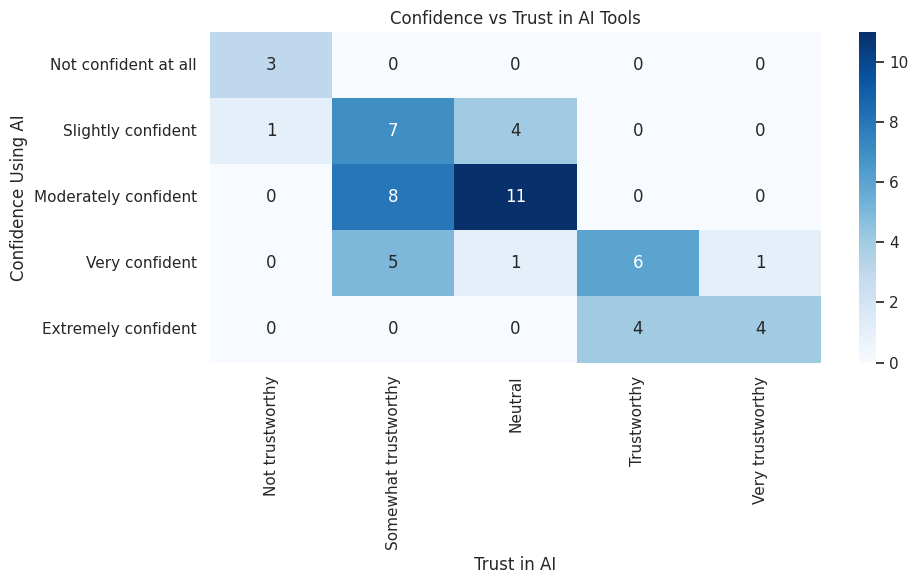

In [9]:
confidence_order = [
    "Not confident at all",
    "Slightly confident",
    "Moderately confident",
    "Very confident",
    "Extremely confident"
]

trust_order = [
    "Not trustworthy",
    "Somewhat trustworthy",
    "Neutral",
    "Trustworthy",
    "Very trustworthy"
]

heatmap_data = confidence_trust.pivot(index="Confidence", columns="Trust", values="Count").fillna(0)

# Reorder only categories that exist in the current dataset
heatmap_data = heatmap_data.reindex([x for x in confidence_order if x in heatmap_data.index])
heatmap_data = heatmap_data[[x for x in trust_order if x in heatmap_data.columns]]

sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="Blues")
plt.title("Confidence vs Trust in AI Tools")
plt.xlabel("Trust in AI")
plt.ylabel("Confidence Using AI")
plt.tight_layout()
plt.show()


In [10]:
# Optional: ordinal relationship check
confidence_score = {
    "Not confident at all": 1,
    "Slightly confident": 2,
    "Moderately confident": 3,
    "Very confident": 4,
    "Extremely confident": 5
}

trust_score = {
    "Not trustworthy": 1,
    "Somewhat trustworthy": 2,
    "Neutral": 3,
    "Trustworthy": 4,
    "Very trustworthy": 5
}

df["confidence_score"] = df["confidence"].map(confidence_score)
df["trust_score"] = df["trust"].map(trust_score)

correlation = df[["confidence_score", "trust_score"]].corr().iloc[0, 1]
print(f"Correlation between confidence and trust: {correlation:.2f}")


Correlation between confidence and trust: 0.75


### Insight

Confidence and trust move together. Students who feel more confident using AI are more likely to report higher trust in AI outputs.

### Business Translation

This suggests trust may be improved through training and familiarity. In a business setting, low trust in a tool may not only reflect tool quality; it may reflect lack of user confidence or insufficient onboarding.


## 8. SQL Analysis 3: Instructor Guidance vs Guideline Clarity

### Business Question

Does guidance from authority figures improve perceived clarity?

This is the strongest governance insight in the dataset.


In [11]:
query = '''
SELECT `Instructor Guidance`, `Guideline Clarity`, COUNT(*) AS Count
FROM survey_data
GROUP BY `Instructor Guidance`, `Guideline Clarity`
ORDER BY `Instructor Guidance`, Count DESC;
'''

guidance_clarity = run_sql(query)
display(guidance_clarity)


,Instructor Guidance,Guideline Clarity,Count
0,"No, never",Very unclear,15
1,"No, never",Somewhat unclear,12
2,"No, never",Neutral,3
3,"No, never",Somewhat clear,1
4,"Not yet, but guidelines mentioned",Somewhat unclear,6
5,"Not yet, but guidelines mentioned",Neutral,3
6,"Not yet, but guidelines mentioned",Very clear,1
7,"Not yet, but guidelines mentioned",Somewhat clear,1
8,"Not yet, but guidelines were mentioned",Somewhat clear,1
9,"Yes, in multiple courses",Somewhat clear,4


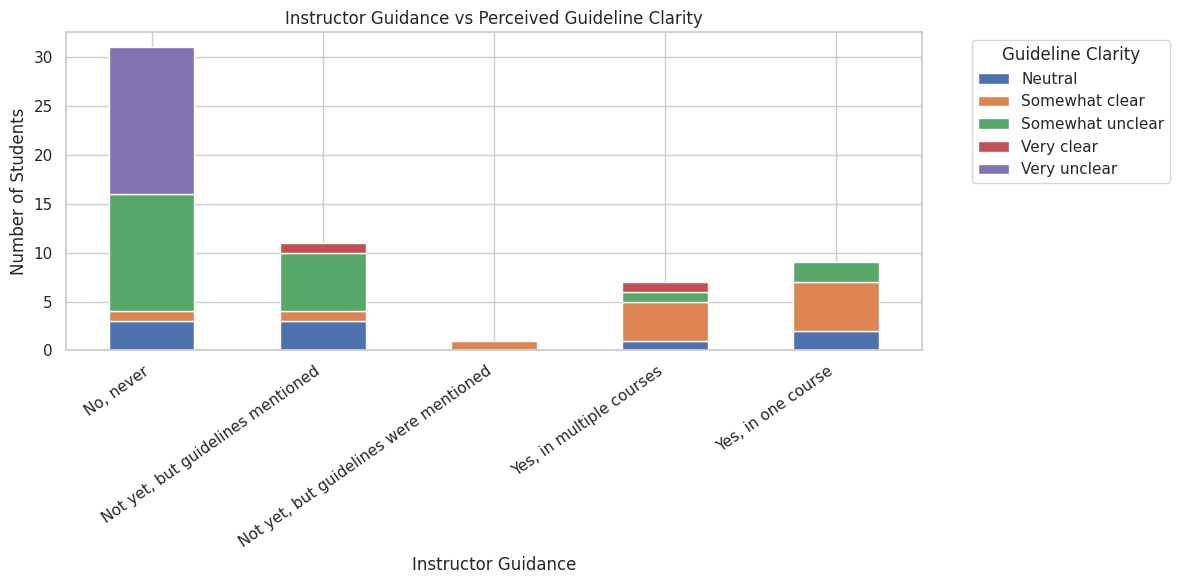

In [12]:
guidance_clarity_pivot = guidance_clarity.pivot(
    index="Instructor Guidance",
    columns="Guideline Clarity",
    values="Count"
).fillna(0)

guidance_clarity_pivot.plot(kind="bar", stacked=True, figsize=(12, 6))
plt.title("Instructor Guidance vs Perceived Guideline Clarity")
plt.xlabel("Instructor Guidance")
plt.ylabel("Number of Students")
plt.xticks(rotation=35, ha="right")
plt.legend(title="Guideline Clarity", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


### Insight

Students who received no instructor guidance were much more likely to report unclear AI guidelines.

### Business Translation

This is a communication and governance problem. When organizations do not clearly explain expectations around a tool, users do not become compliant; they become uncertain, inconsistent, and risk-averse.

### Recommendation

Universities or organizations should provide clear, role-specific AI use guidelines with examples of acceptable and unacceptable use.


## 9. SQL Analysis 4: Daily Users and Learning Impact

### Business Question

Do heavy users report negative outcomes, or do they see AI as useful?

This tests whether frequent use is associated with harmful or positive user experience.


In [13]:
query = '''
SELECT `Learning Impact`, COUNT(*) AS Count
FROM survey_data
WHERE `AI Frequency` = 'Daily'
GROUP BY `Learning Impact`
ORDER BY Count DESC;
'''

daily_learning_impact = run_sql(query)
display(daily_learning_impact)


,Learning Impact,Count
0,"Yes, mostly positive",14
1,"Yes, mostly negative (overdependence)",1
2,"Yes, mixed positive and negative",1


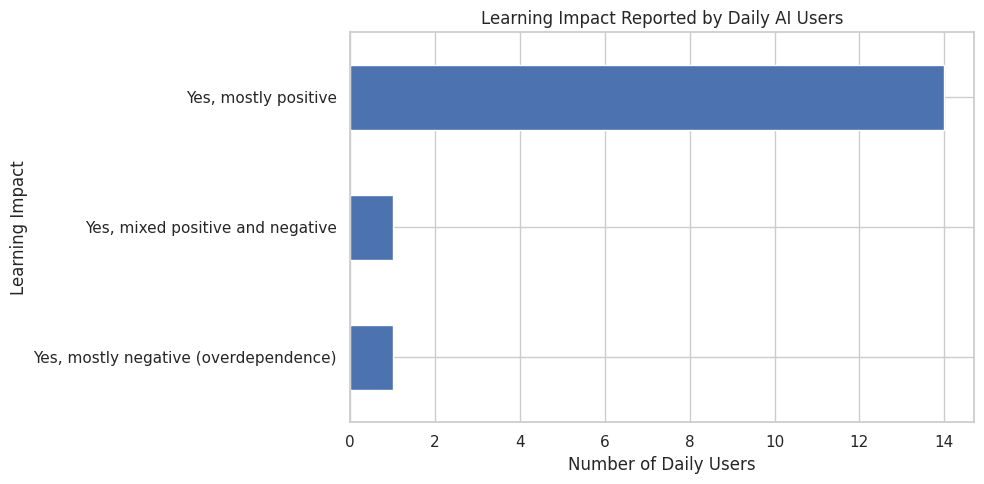

In [14]:
daily_learning_impact.sort_values("Count").plot(
    kind="barh",
    x="Learning Impact",
    y="Count",
    legend=False,
    figsize=(10, 5)
)

plt.title("Learning Impact Reported by Daily AI Users")
plt.xlabel("Number of Daily Users")
plt.ylabel("Learning Impact")
plt.tight_layout()
plt.show()


### Insight

Daily users generally report positive learning outcomes.

### Business Translation

Frequent use does not automatically mean harmful use. In business terms, power users may be the best group to study when designing training, documentation, or best practices.


## 10. SQL Analysis 5: Living Situation vs AI Frequency

### Business Question

Is AI use driven by access constraints or by attitudes, confidence, and institutional context?


In [15]:
query = '''
SELECT `Living Situation`, `AI Frequency`, COUNT(*) AS Count
FROM survey_data
GROUP BY `Living Situation`, `AI Frequency`
ORDER BY `Living Situation`, Count DESC;
'''

living_frequency = run_sql(query)
display(living_frequency)


,Living Situation,AI Frequency,Count
0,Off campus outside Mississauga,A few times a week,11
1,Off campus outside Mississauga,Daily,5
2,Off campus outside Mississauga,Never,2
3,Off campus outside Mississauga,A few times a month,2
4,Off campus outside Mississauga,Less than once a month,1
5,Off campus within Mississauga,Daily,6
6,Off campus within Mississauga,A few times a month,6
7,Off campus within Mississauga,A few times a week,4
8,Off campus within Mississauga,Never,2
9,Off campus within Mississauga,Less than once a month,2


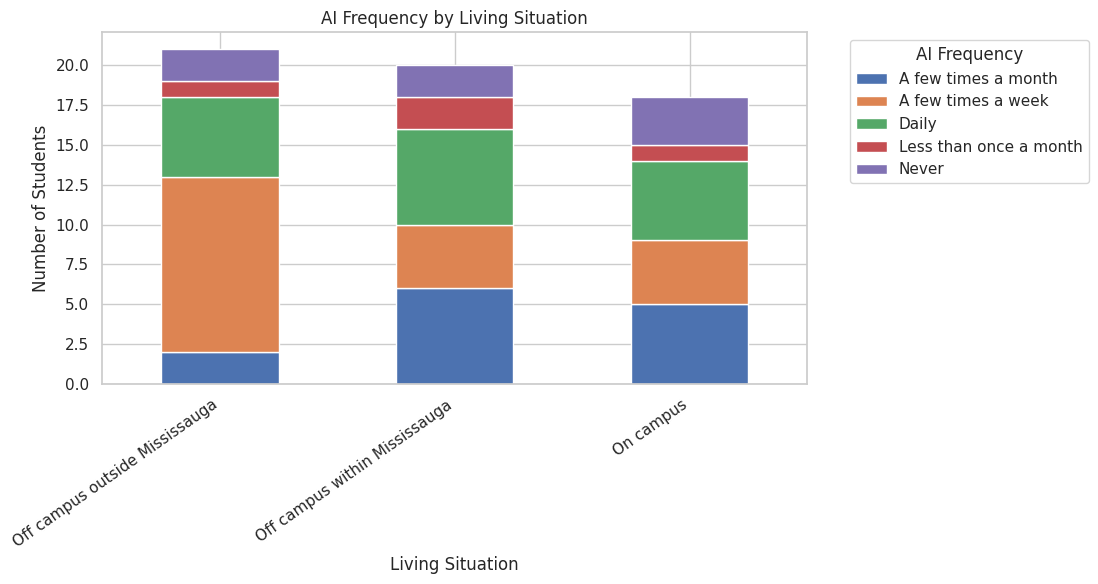

In [16]:
living_freq_pivot = living_frequency.pivot(
    index="Living Situation",
    columns="AI Frequency",
    values="Count"
).fillna(0)

living_freq_pivot.plot(kind="bar", stacked=True, figsize=(11, 6))
plt.title("AI Frequency by Living Situation")
plt.xlabel("Living Situation")
plt.ylabel("Number of Students")
plt.xticks(rotation=35, ha="right")
plt.legend(title="AI Frequency", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


### Insight

Living situation does not appear to meaningfully change AI usage patterns.

### Business Translation

AI use is likely not primarily an access issue. The stronger drivers appear to be confidence, perceived legitimacy, and communication from instructors.


## 11. SQL Analysis 6: Extreme Confidence Segments

### Business Question

What separates the most confident users from the least confident users?

This creates a useful segment comparison: high-confidence adopters vs low-confidence skeptics.


In [17]:
query = '''
SELECT *
FROM survey_data
WHERE Confidence = 'Extremely confident'
   OR Confidence = 'Not confident at all';
'''

confidence_extremes = run_sql(query)
display(confidence_extremes)


,#,Program,Living Situation,AI Frequency,Tools Used,Uses,Confidence,Trust,Guideline Clarity,Instructor Guidance,Learning Impact,Preparedness,Independence
0,4,Social Sciences,Off campus within Mississauga,Daily,ChatGPT,All of the above,Extremely confident,Very trustworthy,Very unclear,"No, never","Yes, mostly positive",Very prepared,Strongly supports
1,6,Sciences,On campus,Never,None,None,Not confident at all,Not trustworthy,Somewhat clear,"No, never",No,Not prepared,Neutral
2,9,Social Sciences,Off campus outside Mississauga,Daily,"ChatGPT, QuillBot, Grammarly",All of the above,Extremely confident,Very trustworthy,Very unclear,"No, never","Yes, mostly positive",Very prepared,Somewhat supports
3,13,Commerce/Management,Off campus within Mississauga,Daily,"ChatGPT, Copilot","Brainstorming, writing assistance, studying/re...",Extremely confident,Trustworthy,Somewhat unclear,"Not yet, but guidelines mentioned","Yes, mostly positive",Very prepared,Somewhat supports
4,16,Sciences,Off campus within Mississauga,Never,None,None,Not confident at all,Not trustworthy,Very clear,"Not yet, but guidelines mentioned",No,Not prepared,Neutral
5,20,Social Sciences,Off campus outside Mississauga,Daily,"ChatGPT, Grammarly, QuillBot",All of the above,Extremely confident,Very trustworthy,Very unclear,"No, never","Yes, mostly positive",Very prepared,Strongly supports
6,25,Humanities,Off campus outside Mississauga,Never,None,None,Not confident at all,Not trustworthy,Somewhat clear,"Yes, in one course",No,Not prepared,Strongly limits
7,26,Computer Science/Math,Off campus within Mississauga,Daily,"ChatGPT, Copilot","Coding help, clarifying concepts, debugging",Extremely confident,Very trustworthy,Somewhat clear,"Yes, in multiple courses","Yes, mostly positive",Very prepared,Somewhat supports
8,33,Commerce/Management,On campus,Daily,"ChatGPT, QuillBot, Grammarly",All of the above,Extremely confident,Trustworthy,Very unclear,"No, never","Yes, mostly positive",Prepared,Somewhat supports
9,39,Commerce/Management,Off campus outside Mississauga,Daily,"ChatGPT, QuillBot",All of the above,Extremely confident,Trustworthy,Very unclear,"No, never","Yes, mostly negative (overdependence)",Somewhat prepared,Somewhat limits


In [18]:
query = '''
SELECT Program, `AI Frequency`, `Tools Used`, Uses, Confidence, Trust, 
       `Guideline Clarity`, `Instructor Guidance`, `Learning Impact`, Preparedness, Independence
FROM survey_data
WHERE Confidence = 'Extremely confident'
   OR Confidence = 'Not confident at all';
'''

confidence_extremes_summary = run_sql(query)
display(confidence_extremes_summary)


,Program,AI Frequency,Tools Used,Uses,Confidence,Trust,Guideline Clarity,Instructor Guidance,Learning Impact,Preparedness,Independence
0,Social Sciences,Daily,ChatGPT,All of the above,Extremely confident,Very trustworthy,Very unclear,"No, never","Yes, mostly positive",Very prepared,Strongly supports
1,Sciences,Never,None,None,Not confident at all,Not trustworthy,Somewhat clear,"No, never",No,Not prepared,Neutral
2,Social Sciences,Daily,"ChatGPT, QuillBot, Grammarly",All of the above,Extremely confident,Very trustworthy,Very unclear,"No, never","Yes, mostly positive",Very prepared,Somewhat supports
3,Commerce/Management,Daily,"ChatGPT, Copilot","Brainstorming, writing assistance, studying/re...",Extremely confident,Trustworthy,Somewhat unclear,"Not yet, but guidelines mentioned","Yes, mostly positive",Very prepared,Somewhat supports
4,Sciences,Never,None,None,Not confident at all,Not trustworthy,Very clear,"Not yet, but guidelines mentioned",No,Not prepared,Neutral
5,Social Sciences,Daily,"ChatGPT, Grammarly, QuillBot",All of the above,Extremely confident,Very trustworthy,Very unclear,"No, never","Yes, mostly positive",Very prepared,Strongly supports
6,Humanities,Never,None,None,Not confident at all,Not trustworthy,Somewhat clear,"Yes, in one course",No,Not prepared,Strongly limits
7,Computer Science/Math,Daily,"ChatGPT, Copilot","Coding help, clarifying concepts, debugging",Extremely confident,Very trustworthy,Somewhat clear,"Yes, in multiple courses","Yes, mostly positive",Very prepared,Somewhat supports
8,Commerce/Management,Daily,"ChatGPT, QuillBot, Grammarly",All of the above,Extremely confident,Trustworthy,Very unclear,"No, never","Yes, mostly positive",Prepared,Somewhat supports
9,Commerce/Management,Daily,"ChatGPT, QuillBot",All of the above,Extremely confident,Trustworthy,Very unclear,"No, never","Yes, mostly negative (overdependence)",Somewhat prepared,Somewhat limits


### Insight

Comparing the confidence extremes helps identify whether the issue is tool access, user experience, or institutional clarity.

### Business Translation

In a business setting, this would support user segmentation:
- **Power users:** confident, trusting, frequent users
- **Cautious users:** moderate confidence, conditional trust
- **Skeptics:** low confidence, low trust, likely requiring clearer guidance or training


## 12. Executive Summary

### Main Story

Students are already using AI tools, but adoption and trust are shaped less by access and more by confidence, discipline, and institutional communication.

### Key Findings

1. **AI adoption is already established.**  
   Students across programs use AI tools, especially ChatGPT, for academic support.

2. **Confidence predicts trust.**  
   Students who feel more confident using AI are more likely to trust AI outputs.

3. **Instructor communication drives clarity.**  
   Students who receive no instructor guidance are more likely to report unclear guidelines.

4. **Daily users report mostly positive learning outcomes.**  
   Heavy use does not necessarily mean harmful use.

5. **Living situation does not appear to drive AI frequency.**  
   This suggests adoption is shaped more by attitudes and guidance than by access.

### Recommendation

Institutions should not rely on silence or vague policies. Clear, course-level guidance and basic AI literacy training would likely reduce confusion, improve responsible use, and support better student outcomes.


## 13. Portfolio Reflection

### Skills Demonstrated

- Data cleaning and preparation  
- SQL querying and aggregation  
- Cross-tabulation and segmentation  
- Exploratory data analysis  
- Data visualization  
- Insight communication for non-technical stakeholders  
- Translating academic survey data into business-style recommendations  

### Why This Matters for Analyst Roles

This project shows the ability to:
- Turn raw survey data into structured insights
- Identify behaviour patterns across user segments
- Connect findings to training, communication, and governance recommendations
- Explain data clearly to stakeholders
